Starting Threading Example
Using Existing Video Stream


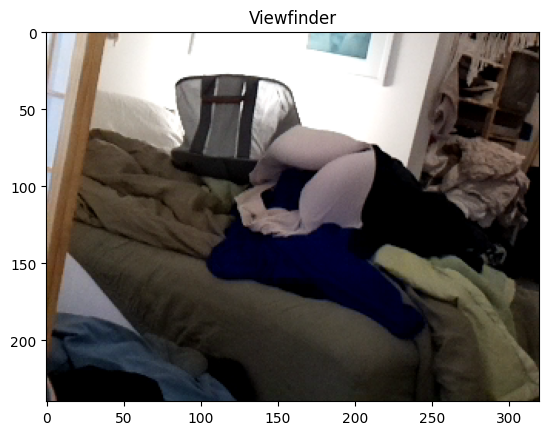

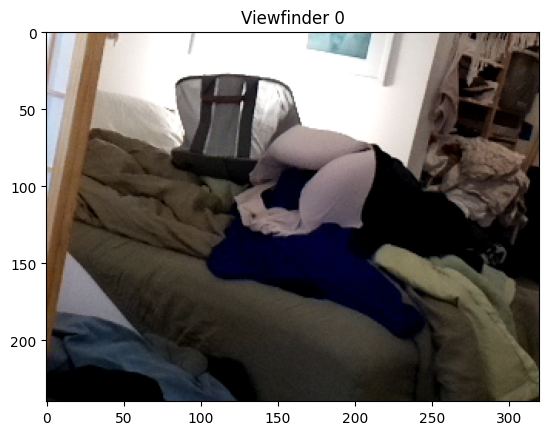

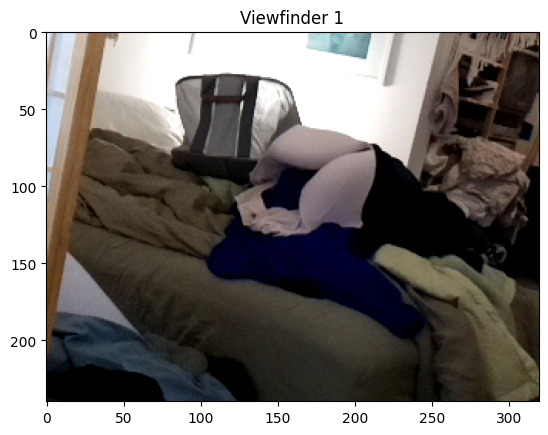

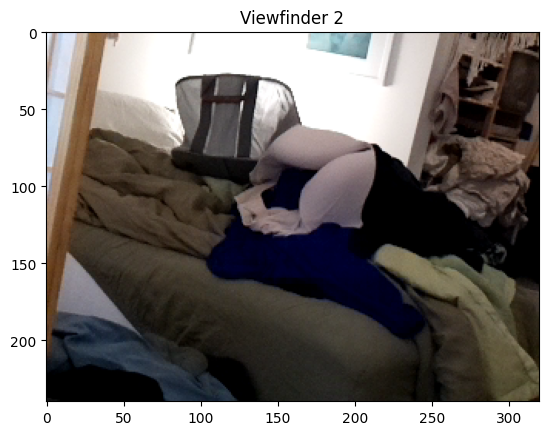

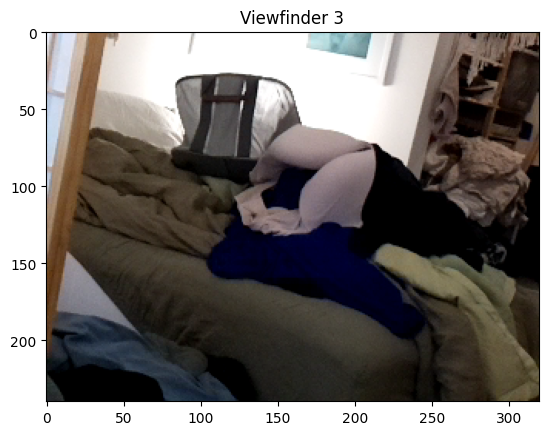

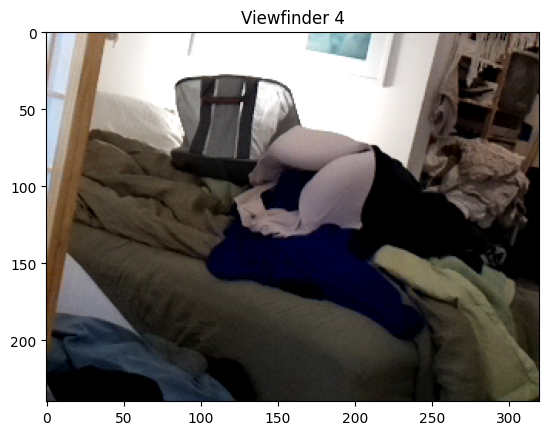

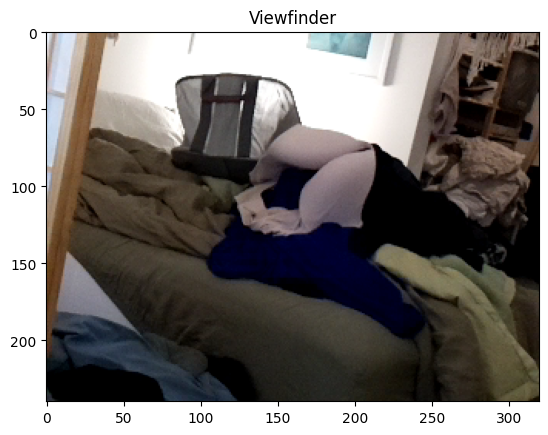

Starting Motion Detection...


AppLayout(children=(Button(description='-INTIALIZE-         4', layout=Layout(grid_area='center'), style=Butto…

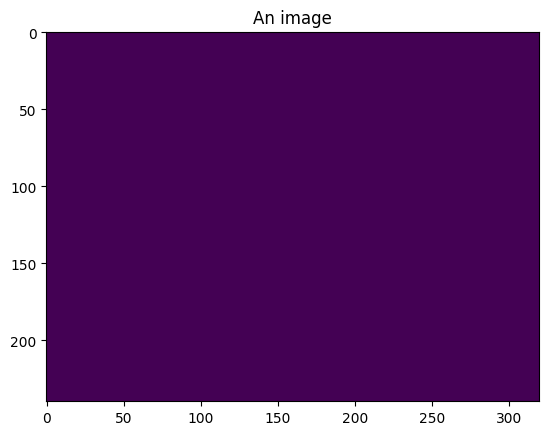

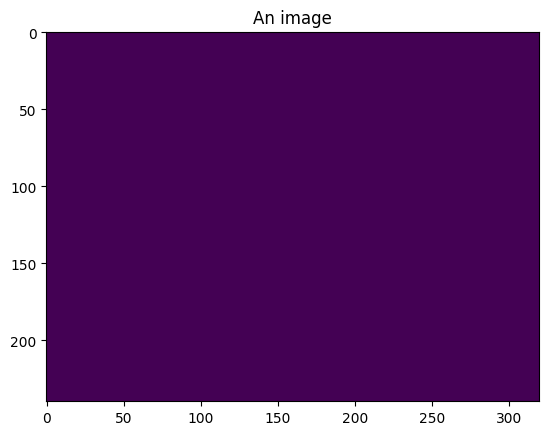

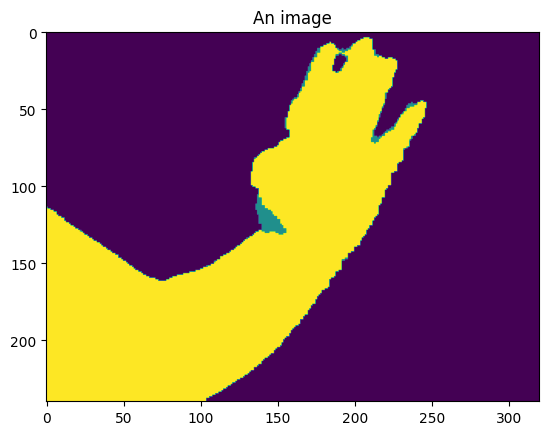

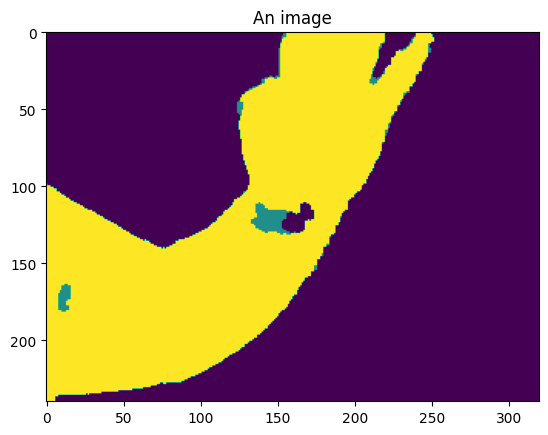

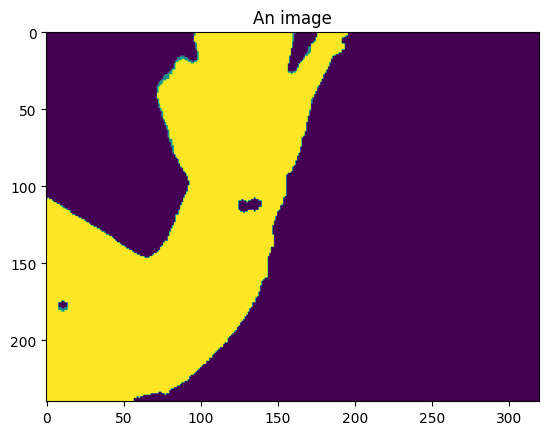

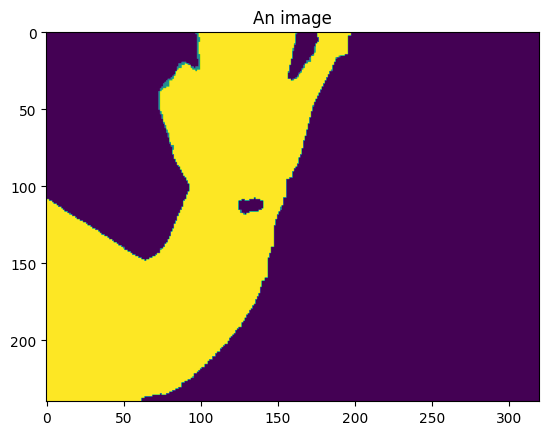

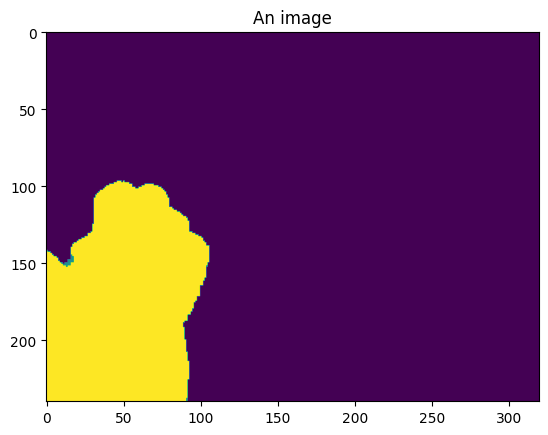

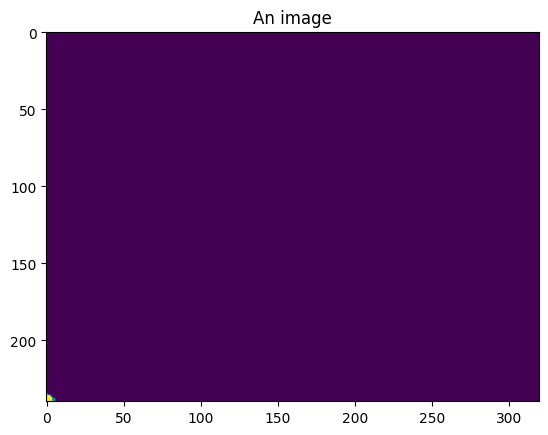

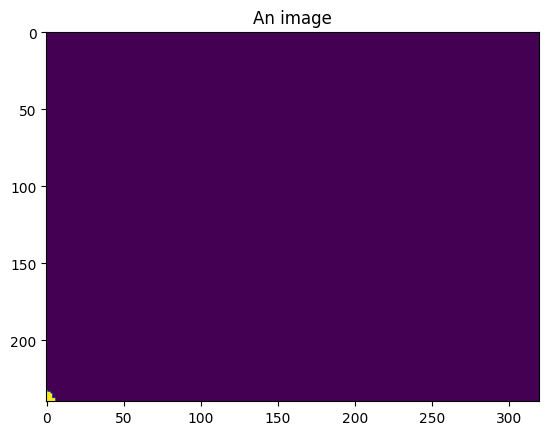

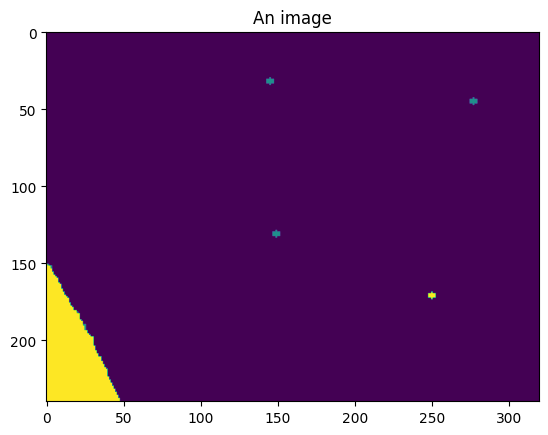

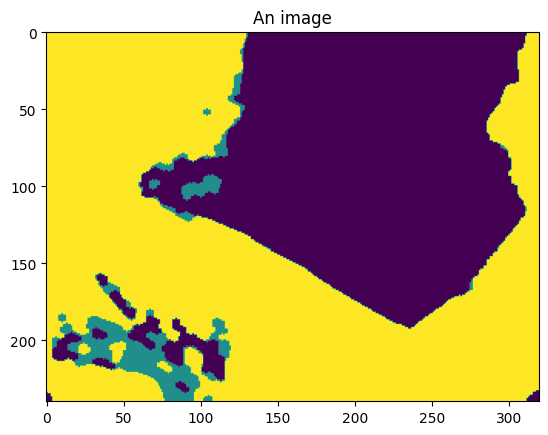

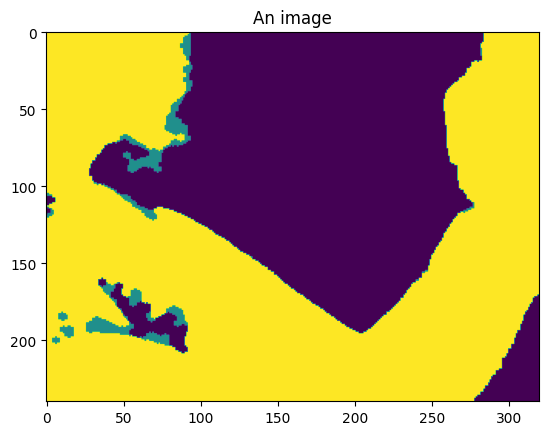

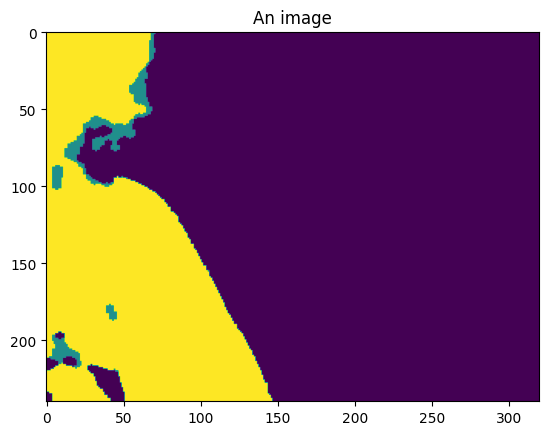

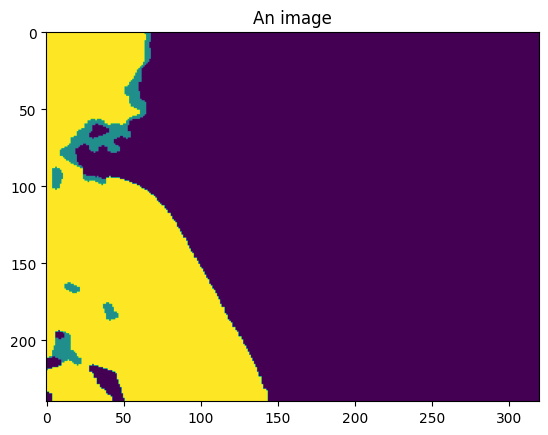

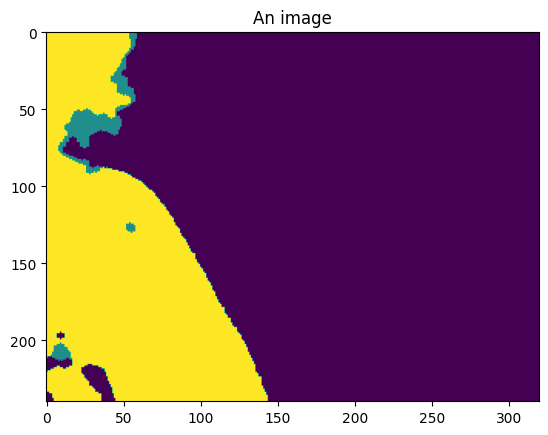

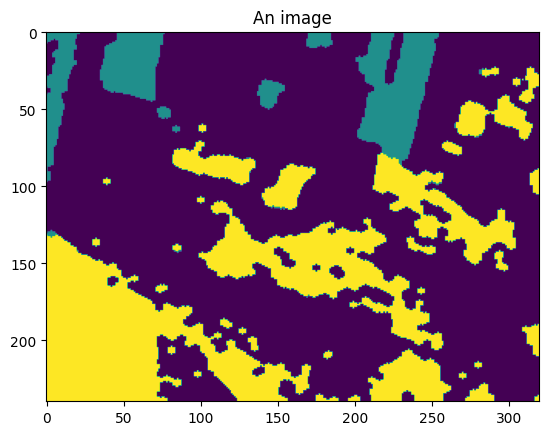

Elasped Time: 20.60
Approx. FPS Processed: 0.78
Total Zero Frames: 2
Total Frames: 16
GRAPHING...


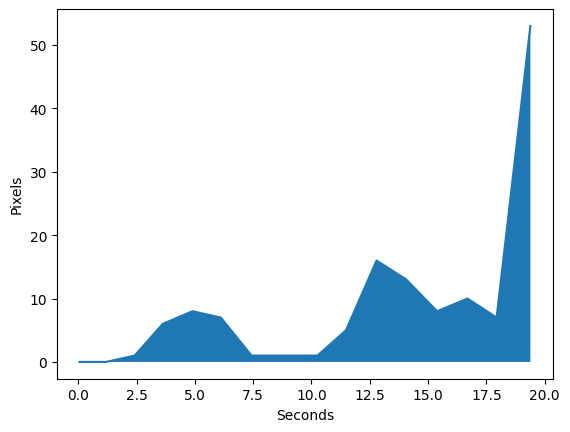

Done


In [9]:
# import the necessary packages
from __future__ import print_function

%matplotlib inline


#from imutils.video.pivideostream import PiVideoStream
from imutils.video import FPS
from picamera.array import PiRGBArray
from picamera import PiCamera
import imutils
import time
import cv2
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from threading import Thread

from ipywidgets import widgets, Layout
 

'''
================
Define a threaded camera "PiVideoStream" class
================
'''

class PiVideoStream:
    def __init__(self, resolution=(160, 128), framerate=90):
        # initialize the camera and stream
        print("Initializing Video Steam")
        self.camera = PiCamera()
        self.camera.resolution = resolution
        self.camera.framerate = framerate
        self.rawCapture = PiRGBArray(self.camera, size=resolution)
        self.stream = self.camera.capture_continuous(self.rawCapture,
            format="rgb", use_video_port=True)
        # SET auto exposure
        self.camera.iso = 800
        self.camera.exposure_mode = 'auto'
        # initialize the frame and the variable used to indicate
        # if the thread should be stopped
        self.frame = None
        self.stopped = False
        self.newframe = True
        
    def start(self):
        # start the thread to read frames from the video stream
        # ======= BEGIN CAMERA THREAD: UPDATE LOOP ============
        Thread(target=self.__update, args=()).start()
        return self
    
    def __update(self):
        # ==== UPDATE LOOP PULLING FRAMES FROM THE STREAM ====
        # keeps looping infinitely until the Thread is stopped
        for f in self.stream:
            # grab the frame from the stream and clear the stream in
            # preparation for the next frame
            self.frame = f.array
            self.rawCapture.truncate(0)
            self.newframe = True #indicate new frame
            # if the thread indicator variable is set, stop the thread
            # and resource camera resources
            if self.stopped:
                self.stream.close()
                self.rawCapture.close()
                self.camera.close()
                return
            
    
    def read(self):
        # return the frame most recently read by update loop
        new = self.newframe
        self.newframe = False #indicate frame already read
        return self.frame, new
    
    def stop(self):
        # indicate that the Thread (update loop) should be stopped
        self.stopped = True
        
'''
================
Initialize Camera
================
'''
        
print("Starting Threading Example")
try:
    image, new_frame = vs.read()
    print("Using Existing Video Stream")
except:
    res=(320, 240)
    vs = PiVideoStream(res).start()
    print("Initialized New Video Stream with", res, "Resolution")
    time.sleep(2.0)
    image, new_frame = vs.read()
    # created a *threaded *video stream, allow the camera sensor to warmup,
    # and start the FPS counter

    
'''
================
Initialize background removal
================
'''
backSub = cv2.createBackgroundSubtractorMOG2() # Create background remover
ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))



initBB = None
'''
================
Example Code
================
'''
run_time = 20 #seconds
data = np.zeros([run_time*20,2])


plt.imshow(image)
plt.title('Viewfinder')
plt.show()

init_text = "-INTIALIZE-"
init_color = 'green'
no_motion_text = "--------"
no_motion_color = 'white'
motion_text = "-FOUND-"
motion_color = 'red'
button = widgets.Button(description=no_motion_text)
button.style.button_color = no_motion_color   


start_time = time.time()

for i in range(5):
    image2, new_frame = vs.read()
    plt.imshow(image2)
    plt.title('Viewfinder ' + str(i))
    plt.show()
    button.description=init_text+str(i).rjust(10)
    button.style.button_color = init_color
    while time.time()-start_time< i:
        pass

vs.camera.exposure_mode = 'off'
image2, new_frame = vs.read()
plt.imshow(image2)
plt.title('Viewfinder')
plt.show()
background = image2

_ = backSub.apply(background)

sensor_info = widgets.AppLayout(center=button) # place the bar and text side by side

movement_threshold=50 

show_images = True
start_time = time.time()
zero_frames = 0
total_frames = 0

print("Starting Motion Detection...")
display(sensor_info) # display the bar and text


fps = FPS().start() # begin fps counter & timer



# loop over some frames...this time using the threaded stream
while time.time()-start_time<run_time:
    

        # grab the frame from the threaded video stream 
        image2, new_frame = vs.read()

        if new_frame: #Only process new frames from stream
            
            
            #diff = cv2.absdiff(image2, background)
            #gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

            # threshold the difference to find motion/changes
            #thresh = cv2.threshold(gray, movement_threshold, 255, cv2.THRESH_BINARY)[1]
            
            thresh = backSub.apply(image2, learningRate=.01)
            thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, ellipse)
            thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, ellipse)
            
            
            edges = cv2.Canny(thresh, 30, 200) 
           
            contours, hierarchy = cv2.findContours(edges,  
                    cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            
            count = len(contours)

         
                
#             if success:
#                 (x, y, w, h) = [int(v) for v in box]
#                 delta_x = x-old_x
#                 delta_y = y-old_y
#             else:
#                 delta_x = 0
#                 delta_y = 0

#             old_x = x
#             old_y = y
            
#             if delta_x**2+delta_y**2>movement_threshold:
#                 motion = delta_x**2+delta_y**2
#             else:
#                 motion = 0
                
            data[total_frames,:] = [time.time(), count]
            #print(motion)

            if count>0:
                button.description=motion_text+str(count).rjust(10)
                button.style.button_color = motion_color

            else:
                button.description=no_motion_text
                button.style.button_color = no_motion_color
                zero_frames += 1

            if show_images & success:
                #(x, y, w, h) = [int(v) for v in box]
                #cv2.rectangle(image2, (x, y), (x + w, y + h), (0, 255, 0), 2)
                plt.imshow(edges)
                plt.title('An image')
                plt.show()

            total_frames += 1
            fps.update() # update the FPS frame count
        image = image2
    
# stop the timer and display FPS information
fps.stop()


# do a bit of cleanup


#Remove camera
vs.stop()
vs=None

button.description="DONE"
button.style.button_color = "green"  

print(f"Elasped Time: {fps.elapsed():.2f}") # total time since FPS started
print(f"Approx. FPS Processed: {fps.fps():.2f}") # total time since FPS started / number of frames
print(f"Total Zero Frames: {zero_frames:,}")
print(f"Total Frames: {total_frames:,}")

#Graphing
print("GRAPHING...")
df = pd.DataFrame({'Time':  data[:total_frames,0]-start_time, 'Data': data[:total_frames,1]})

plt.plot(df['Time'], df['Data'])
plt.fill_between(df['Time'], df['Data'])
plt.xlabel('Seconds')
plt.ylabel('Pixels')
plt.show()

# df.hist(column=["Data"],bins=50)
# plt.show()

print("Done")

